
***

## Breast Cancer Classification  

Given *data about breast cancer in Wisconsin*, let's try to predict if a given tumor is **malignant**.

We will use a logistic regression model to make our predictions. We will use principal component analysis to reduce the dimension of the data and show that the same results can be achieved with a smaller number of features.


**1️⃣ Purpose of PCA:**  
Principal Component Analysis (PCA) is used to reduce the high-dimensional feature space (26 features) into **2 principal components**.  
This allows us to **visualize the data and model behavior** in a 2D plot.  

**2️⃣ Why Decision Boundary:**  
After training a logistic regression model on the 2D PCA-transformed data, we can plot the **decision boundary**,  
which shows **how the model separates Malignant (1) and Benign (0) samples** in the PCA space.  

**3️⃣ Key Notes:**  
- The PCA model is **used only for visualization purposes**.  
- The **actual prediction model** uses all 26 features.  
- The visualization helps to **understand the model's behavior** and see where borderline samples are.  


In [101]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D


from sklearn.linear_model import LogisticRegression

In [102]:
data = pd.read_csv(r"C:\Users\ExTrA\Downloads\data (6).csv")

In [103]:
data

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [104]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [105]:
data['diagnosis'].unique()

array(['M', 'B'], dtype=object)

# Preprocessing

In [106]:
data = data.drop(['id', 'Unnamed: 32'], axis=1)

In [107]:
data.drop(["symmetry_se","texture_se","fractal_dimension_mean","smoothness_se"],axis=1,inplace=True)

In [108]:
data["diagnosis"] = [1 if value=="M" else 0 for value in data["diagnosis"]]

In [109]:
data

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [110]:
y = data['diagnosis'].copy()
X = data.drop('diagnosis', axis=1).copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)

In [111]:
X_train

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,radius_se,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
559,11.51,23.93,74.52,403.5,0.09261,0.10210,0.11120,0.04105,0.1388,0.2388,...,12.48,37.16,82.28,474.2,0.12980,0.2517,0.36300,0.09653,0.2112,0.08732
295,13.77,13.27,88.06,582.7,0.09198,0.06221,0.01063,0.01917,0.1592,0.2191,...,14.67,16.93,94.17,661.1,0.11700,0.1072,0.03732,0.05802,0.2823,0.06794
264,17.19,22.07,111.60,928.3,0.09726,0.08995,0.09061,0.06527,0.1867,0.4203,...,21.58,29.33,140.50,1436.0,0.15580,0.2567,0.38890,0.19840,0.3216,0.07570
125,13.85,17.21,88.44,588.7,0.08785,0.06136,0.01420,0.01141,0.1614,0.2185,...,15.49,23.58,100.30,725.9,0.11570,0.1350,0.08115,0.05104,0.2364,0.07182
280,19.16,26.60,126.20,1138.0,0.10200,0.14530,0.19210,0.09664,0.1902,0.6361,...,23.72,35.90,159.80,1724.0,0.17820,0.3841,0.57540,0.18720,0.3258,0.09720
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,11.60,12.84,74.34,412.6,0.08983,0.07525,0.04196,0.03350,0.1620,0.2315,...,13.06,17.16,82.96,512.5,0.14310,0.1851,0.19220,0.08449,0.2772,0.08756
322,12.86,13.32,82.82,504.8,0.11340,0.08834,0.03800,0.03400,0.1543,0.2212,...,14.04,21.08,92.80,599.5,0.15470,0.2231,0.17910,0.11550,0.2382,0.08553
382,12.05,22.72,78.75,447.8,0.06935,0.10730,0.07943,0.02978,0.1203,0.1194,...,12.57,28.71,87.36,488.4,0.08799,0.3214,0.29120,0.10920,0.2191,0.09349
365,20.44,21.78,133.80,1293.0,0.09150,0.11310,0.09799,0.07785,0.1618,0.5781,...,24.31,26.37,161.20,1780.0,0.13270,0.2376,0.27020,0.17650,0.2609,0.06735


In [112]:
scaler = StandardScaler()
scaler.fit(X_train)

X_train = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns)
X_test  = pd.DataFrame(scaler.transform(X_test), columns=X_train.columns)


In [113]:
X_train

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,radius_se,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,-0.754501,1.016591,-0.731287,-0.732655,-0.244628,-0.046204,0.276113,-0.209613,-1.463648,-0.641618,...,-0.786560,1.835601,-0.748038,-0.715894,-0.048296,0.013325,0.464941,-0.272555,-1.224122,0.246375
1,-0.107318,-1.377551,-0.167357,-0.212302,-0.290236,-0.806690,-0.982285,-0.780715,-0.758709,-0.714886,...,-0.330400,-1.399872,-0.391399,-0.384622,-0.624296,-0.968536,-1.127291,-0.871529,-0.081993,-0.899752
2,0.872048,0.598852,0.813064,0.791235,0.092006,-0.277838,0.018477,0.422567,0.191577,0.033417,...,1.108900,0.583315,0.998261,0.988855,1.121705,0.047299,0.591565,1.311903,0.549310,-0.440828
3,-0.084408,-0.492662,-0.151531,-0.194880,-0.589225,-0.822895,-0.937614,-0.983264,-0.682686,-0.717118,...,-0.159600,-0.336308,-0.207531,-0.269767,-0.682796,-0.779638,-0.913008,-0.980094,-0.819317,-0.670290
4,1.436186,1.616250,1.421142,1.400153,0.435156,0.777386,1.288387,1.241373,0.312522,0.836020,...,1.554646,1.634084,1.577161,1.499322,2.129706,0.912967,1.503354,1.137701,0.616777,0.830675
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
393,-0.728728,-1.474125,-0.738784,-0.706231,-0.445884,-0.558088,-0.590263,-0.406680,-0.661953,-0.668768,...,-0.665750,-1.363087,-0.727641,-0.648009,0.550204,-0.439214,-0.370091,-0.459822,-0.163918,0.260568
394,-0.367909,-1.366321,-0.385599,-0.438505,1.260452,-0.308532,-0.639813,-0.393629,-0.928033,-0.707076,...,-0.461624,-0.736144,-0.432492,-0.493805,1.072205,-0.181009,-0.434136,0.022499,-0.790402,0.140515
395,-0.599864,0.744836,-0.555111,-0.604019,-1.928521,0.052932,-0.121414,-0.503778,-2.102931,-1.085690,...,-0.767814,0.484155,-0.595664,-0.690725,-1.929747,0.486928,0.113915,-0.075490,-1.097219,0.611267
396,1.802732,0.533720,1.737676,1.850235,-0.324985,0.163507,0.110821,0.750925,-0.668864,0.620306,...,1.677538,0.109909,1.619153,1.598580,0.082204,-0.082483,0.011247,0.971276,-0.425756,-0.934645


# Principal Component Analysis (Dimensionality Reduction)

In [114]:
n_components = 3

pca = PCA(n_components=n_components)
pca.fit(X_train)

pc_train = pd.DataFrame(pca.transform(X_train), columns=["PC" + str(i + 1) for i in range(n_components)])
pc_test = pd.DataFrame(pca.transform(X_test), columns=["PC" + str(i + 1) for i in range(n_components)])

In [115]:
pc_train

,PC1,PC2,PC3
0,-1.248222,0.913039,-0.426273
1,-3.246629,-1.217379,0.116933
2,1.819268,-1.717178,1.882526
3,-3.037517,-1.565069,0.195319
4,5.079377,-1.006789,1.949790
...,...,...,...
393,-2.816273,0.545472,0.565505
394,-1.796863,0.699792,0.745355
395,-1.707792,0.805402,-2.115015
396,2.973906,-3.557906,-0.012269


In [116]:
# Show how much variance each PC explainsprint(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_)

[0.50405093 0.17950315 0.0886217 ]


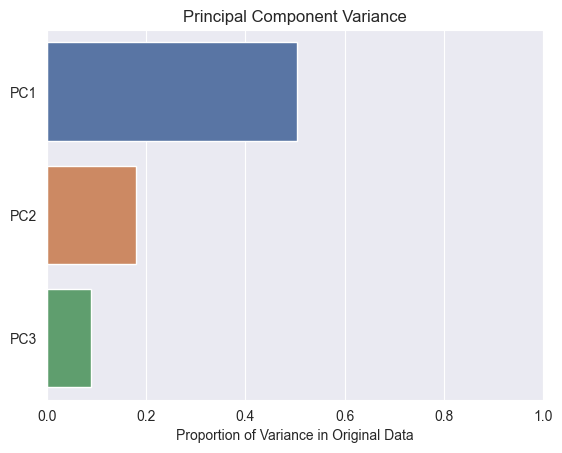

In [117]:
# Plot the proportion of variance explained by each PC
labels = ["PC" + str(i + 1) for i in range(n_components)]
sns.barplot(
    x=pca.explained_variance_ratio_,
    y=labels,
    hue=labels,
    orient='h',
    palette='deep',
    legend=False
)
plt.xlim(0., 1.)
plt.xlabel("Proportion of Variance in Original Data")
plt.title("Principal Component Variance")
plt.show()

# Training/Results

In [118]:
# On the original data
original_model = LogisticRegression()
original_model.fit(X_train, y_train)

print("Model Accuracy (Original Data): {:.5f}%".format(original_model.score(X_test, y_test) * 100))

Model Accuracy (Original Data): 99.41520%


In [119]:
# On the principal components
pca_model = LogisticRegression()
pca_model.fit(pc_train, y_train)

print("Model Accuracy (PCA Data): {:.5f}%".format(pca_model.score(pc_test, y_test) * 100))

Model Accuracy (PCA Data): 98.24561%


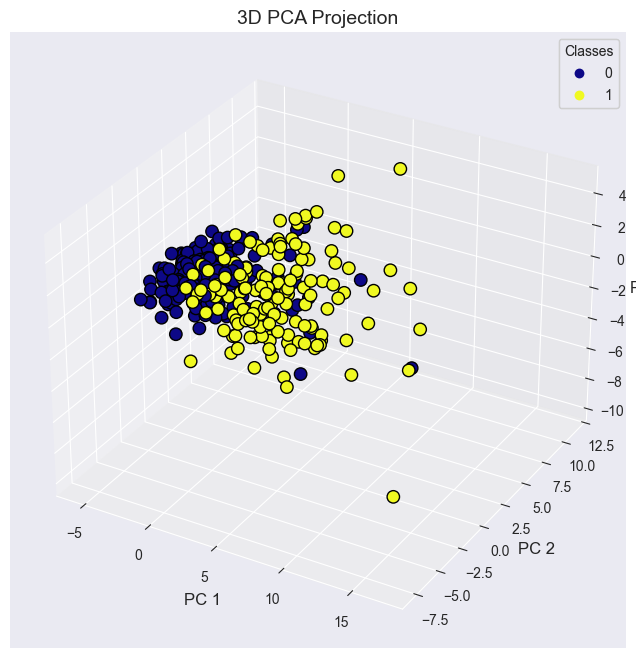

In [120]:
# Reduce data to 3 dimensions
pca_3 = PCA(n_components=3)
X_pca_3 = pca_3.fit_transform(X_train)

# Create 3D scatter plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the points with colors for each class
scatter = ax.scatter(
    X_pca_3[:, 0], X_pca_3[:, 1], X_pca_3[:, 2],
    c=y_train,          # Class labels
    cmap='plasma',      # Dark and vivid colors
    s=80,               # Point size
    edgecolor='k',      # Black edges
    alpha=1             # Full opacity
)

# Set axis labels and title
ax.set_xlabel('PC 1', fontsize=12)
ax.set_ylabel('PC 2', fontsize=12)
ax.set_zlabel('PC 3', fontsize=12)
ax.set_title('3D PCA Projection', fontsize=14)

# Add legend for classes
legend1 = ax.legend(*scatter.legend_elements(), title="Classes")
ax.add_artist(legend1)

plt.show()


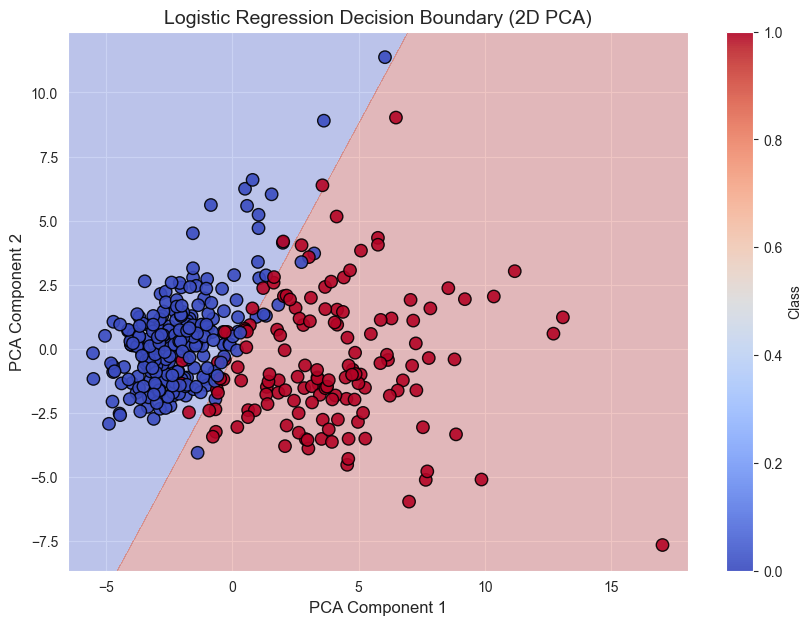

In [121]:
# Reduce to 2D using PCA 
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train)  # X_train_sc هي الداتا بعد scaling

#  Fit the Logistic Regression model 
model_logreg = LogisticRegression()
model_logreg.fit(X_train_2d, y_train)

# Create meshgrid for decision boundary 
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

# Predict classes for each point in the grid
Z = model_logreg.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 7))
# Decision boundary
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

# Scatter plot of training points
plt.scatter(
    X_train_2d[:, 0],
    X_train_2d[:, 1],
    c=y_train,             
    cmap=plt.cm.coolwarm,
    edgecolor='k',
    s=80,                  
    alpha=0.9
)

plt.title("Logistic Regression Decision Boundary (2D PCA)", fontsize=14)
plt.xlabel("PCA Component 1", fontsize=12)
plt.ylabel("PCA Component 2", fontsize=12)
plt.colorbar(label="Class")  
plt.show()


<div style="font-family:Arial, sans-serif; line-height:1.5; color:#1a1a1a; background-color:#f9f9f9; padding:15px; border-radius:10px; box-shadow: 2px 2px 10px #ccc;">
  <h2 style="color:#2c3e50;">PCA Analysis & Model Accuracy</h2>
  
  <p>In this project, we trained a <strong>Logistic Regression</strong> model to predict breast cancer and compared performance before and after applying <strong>PCA</strong>.</p>
  
  <h3 style="color:#34495e;">Results:</h3>
  <ul>
    <li><strong>Original Data Accuracy:</strong> 99.42%</li>
    <li><strong>PCA Data Accuracy:</strong> 98.25%</li>
  </ul>
  
  <h3 style="color:#34495e;">Insights:</h3>
  <ul>
    <li>PCA reduces the number of features while keeping most of the important information.</li>
    <li>Accuracy dropped slightly (~1%), but the model is simpler and faster.</li>
    <li>PCA is useful for optimizing models and reducing complexity without losing much performance.</li>
  </ul>
  
  <p style="color:#e67e22;"><strong>Conclusion:</strong> Dimensionality reduction via PCA is an effective preprocessing step, maintaining high accuracy while simplifying the model.</p>
</div>


<div style="background: linear-gradient(135deg, #6a11cb 0%, #2575fc 100%); 
            border-radius:15px; padding:25px; margin-top:30px; box-shadow: 2px 2px 15px #555;">
  <h2 style="color:#ffffff; text-align:center; font-family:Arial, sans-serif;">Team Members</h2>
  <p style="text-align:center; font-size:16px; color:#e0e0e0; font-family:Arial, sans-serif;">
  
  </p>
  <ul style="list-style-type:none; text-align:center; padding:0; font-size:15px; color:#ffffff; font-family:Arial, sans-serif;">
    <li style="margin:5px 0;">احمد محمد احمد علي سيداحمد</li>
    <li style="margin:5px 0;">مؤمن احمد احمد العناني</li>
    <li style="margin:5px 0;">كريم ابراهيم رخا</li>
    <li style="margin:5px 0;">زياد محمد طه أحمد</li>
    <li style="margin:5px 0;">احمد ياسر محمد صادق</li>
    <li style="margin:5px 0;">حمزه ايهاب ابراهيم احمد</li>
    <li style="margin:5px 0;">مازن السيد محمد احمد موسى الوفائي</li>
    <li style="margin:5px 0;">عمر حسن محمد رشدى</li>
  </ul>
</div>
